In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

## 1. Usa el dataset breast_cancer de sklearn.datasets.

In [57]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Shape: ", X.shape)
print(pd.Series(y).value_counts())
print(pd.Series(y).value_counts(normalize = True))
print(data.target_names)

Shape:  (569, 30)
1    357
0    212
Name: count, dtype: int64
1    0.627417
0    0.372583
Name: proportion, dtype: float64
['malignant' 'benign']


## 2. Entrena un modelo de Regresión Logística.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state = 27)

In [59]:
modelo=LogisticRegression(max_iter=20000)
modelo.fit(X_train,y_train)
y_pred=modelo.predict(X_test)
y_prob=modelo.predict_proba(X_test)[:,1]

## 3. Genera e interpreta la Matriz de Confusión.

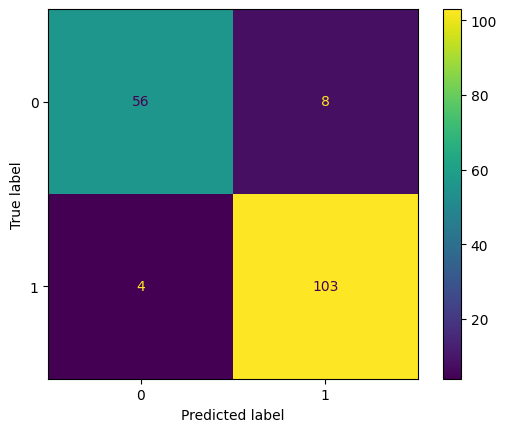

[[ 56   8]
 [  4 103]]


In [60]:
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
print(cm)

La matriz de confusión nos devolvió 103 positivos verdaderos y 56 negativos verdaderos, por lo que la mayoría de las predicciones fueron acertadas, sin embargo, hubieron 4 falsos negativos, los cuales de por si no son tan preocupantes, pero también hubieron 8 falsos positivos los cuales sí son preocupantes ya que significan que hay 8 pacientes que padecen de cáncer maligno pero fueron diagnosticados como cáncer benigno.

## 4. Calcula Precisión, Recall, F1-Score y AUC-ROC.

Precisión: 0.9279279279279279
Recall: 0.9626168224299065
F1-Score: 0.944954128440367
AUC-ROC: 0.9897780373831776


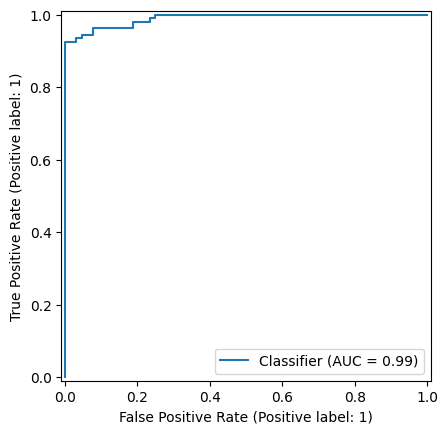

In [61]:
precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

r_s = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", r_s)
RocCurveDisplay.from_predictions(y_test,y_prob)
plt.show()

## 5. Aplica K-Fold Cross-Validation con k=5 y k=10, y compara los resultados.

In [62]:
print("k=5",cross_val_score(modelo,X,y,cv=5,scoring="roc_auc").mean())
print("k=10",cross_val_score(modelo,X,y,cv=10,scoring="roc_auc").mean())

k=5 0.9924782978664407
k=10 0.9922084793513364


Ambos resultados son bastante cercanos al 1 con una diferencia de apenas 0.027% aproximadamente. Esto significa que para ambos particionamientos el modelo va a tener una buena capacidad de distinguir entre maligno y benigno.

In [72]:
grid=GridSearchCV(LogisticRegression(max_iter=20000), param_grid={"C":[0.01,0.1,1,10,100]}, scoring="roc_auc")
grid.fit(X_train,y_train)
print("Parámetros:", grid.cv_results_["param_C"])
print("Resultados:", grid.cv_results_["mean_test_score"])
print("Mejor C:", grid.best_params_["C"], ", con resultado: ", grid.best_score_)

Parámetros: [0.01 0.1 1.0 10.0 100.0]
Resultados: [0.98811494 0.98987126 0.98973333 0.99026207 0.98957701]
Mejor C: 10 , con resultado:  0.9902620689655173


## 7. Ajusta el umbral de decisión y analiza el impacto en las métricas.

In [73]:
for umbral in [0.3,0.5,0.7]:
    pred=(y_prob>=umbral).astype(int)
    print("\nUmbral:",umbral)
    print("Precisión:",precision_score(y_test,pred))
    print("Recall:",recall_score(y_test,pred))
    print("F1:",f1_score(y_test,pred))


Umbral: 0.3
Precisión: 0.9035087719298246
Recall: 0.9626168224299065
F1: 0.9321266968325792

Umbral: 0.5
Precisión: 0.9279279279279279
Recall: 0.9626168224299065
F1: 0.944954128440367

Umbral: 0.7
Precisión: 0.9532710280373832
Recall: 0.9532710280373832
F1: 0.9532710280373832
